## 1. Project Title

College Placement Analysis

## 2. Dataset Used

Campus Recruitment Dataset

Total Records: 215
Features: Gender, SSC %, HSC %, Degree %, Work Experience, MBA %, Specialization, Placement Status, Salary

## 3. Data Understanding

In [48]:
import pandas as pd
df = pd.read_csv("Placement_Data_Full_Class.csv")
print(df.head())
print(df.info())
print(df.describe())

   sl_no gender  ssc_p    ssc_b  hsc_p    hsc_b     hsc_s  degree_p  \
0      1      M  67.00   Others  91.00   Others  Commerce     58.00   
1      2      M  79.33  Central  78.33   Others   Science     77.48   
2      3      M  65.00  Central  68.00  Central      Arts     64.00   
3      4      M  56.00  Central  52.00  Central   Science     52.00   
4      5      M  85.80  Central  73.60  Central  Commerce     73.30   

    degree_t workex  etest_p specialisation  mba_p      status    salary  
0   Sci&Tech     No     55.0         Mkt&HR  58.80      Placed  270000.0  
1   Sci&Tech    Yes     86.5        Mkt&Fin  66.28      Placed  200000.0  
2  Comm&Mgmt     No     75.0        Mkt&Fin  57.80      Placed  250000.0  
3   Sci&Tech     No     66.0         Mkt&HR  59.43  Not Placed       NaN  
4  Comm&Mgmt     No     96.8        Mkt&Fin  55.50      Placed  425000.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column       

## Missing Values

In [49]:
print(df.isnull().sum())

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64


## Placement Status Distribution

In [50]:
print(df['status'].value_counts())

status
Placed        148
Not Placed     67
Name: count, dtype: int64


#  4. Visualizations
Placement Status

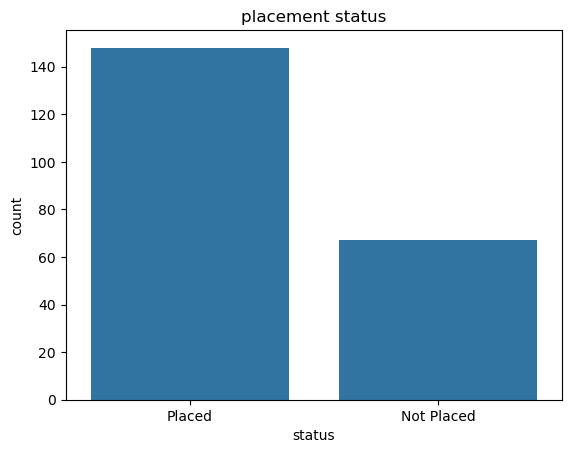

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='status', data=df)
plt.title("placement status")
plt.show()


Gender-wise Placement

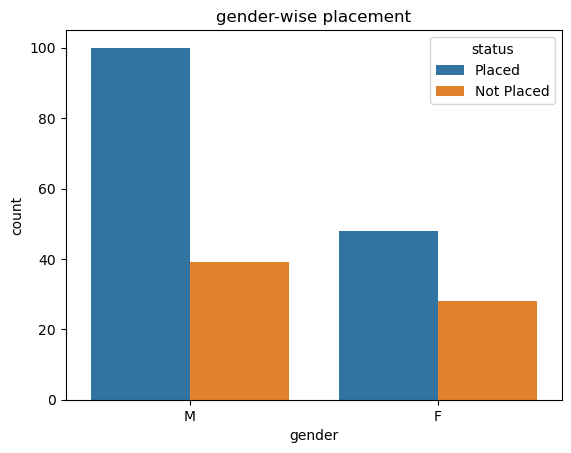

In [52]:
sns.countplot(x='gender', hue='status', data=df)
plt.title("gender-wise placement")
plt.show()

Specialization-wise Placement

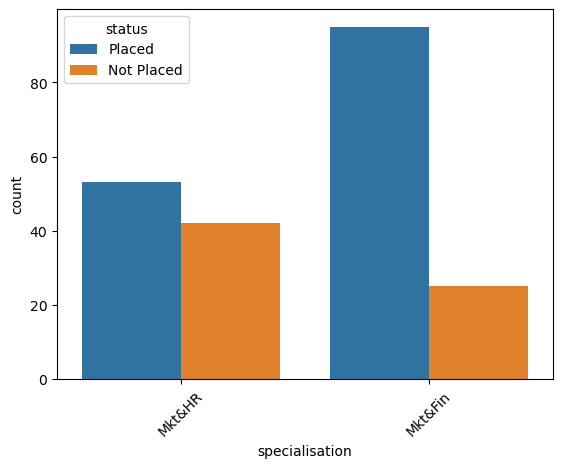

In [53]:
sns.countplot(x='specialisation', hue='status', data=df)
plt.xticks(rotation=45)
plt.show()

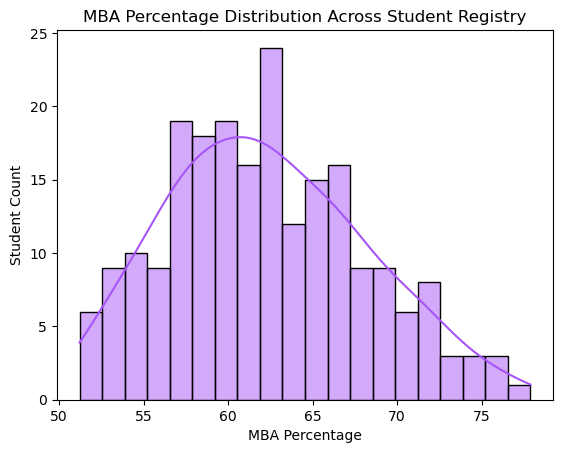

In [54]:
sns.histplot(data=df, x='mba_p', bins=20, kde=True, color='#a855f7').set(
    title='MBA Percentage Distribution Across Student Registry',
    xlabel='MBA Percentage',
    ylabel='Student Count'
)
plt.show()


Salary Distribution

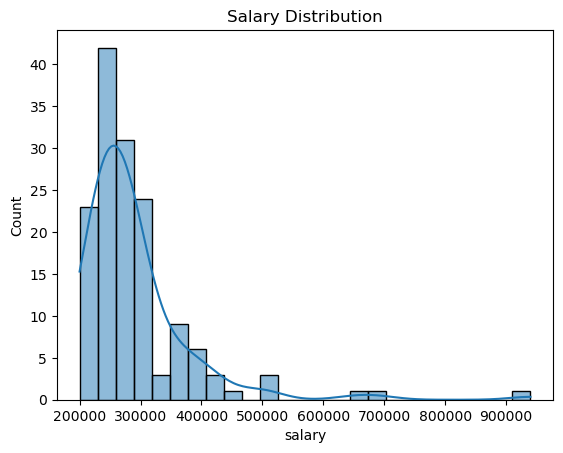

In [55]:
sns.histplot(df['salary'].dropna(), kde=True)
plt.title("Salary Distribution")
plt.show()

Bivariate Contingency Cross-Tabulations

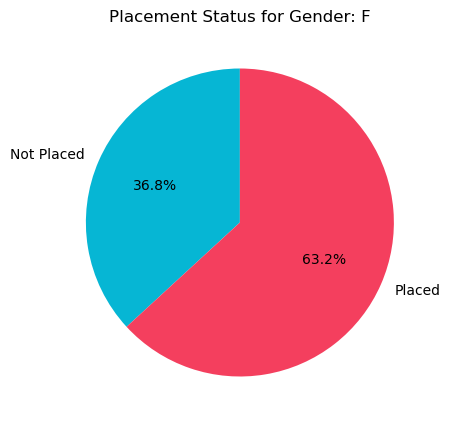

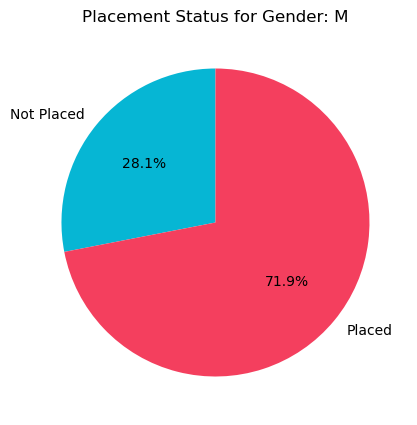

In [56]:
import matplotlib.pyplot as plt

# Clean column names
df.columns = df.columns.str.strip()

# Find correct target column automatically
possible_targets = ['target', 'status', 'placed', 'placement', 'Placement']
target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    print("Target column not found. Available columns:", df.columns.tolist())

else:
    # Gender-wise placement distribution
    gender_counts = df.groupby('gender')[target_col].value_counts().unstack()

    # Pie chart for each gender
    for gender in gender_counts.index:
        plt.figure(figsize=(5,5))
        gender_counts.loc[gender].plot(
            kind='pie',
            autopct='%1.1f%%',
            startangle=90,
            colors=['#06b6d4', '#f43f5e']
        )

        plt.title(f'Placement Status for Gender: {gender}')
        plt.ylabel('')  # hide ylabel
        plt.show()

 Specialization vs. Placement Outcomes

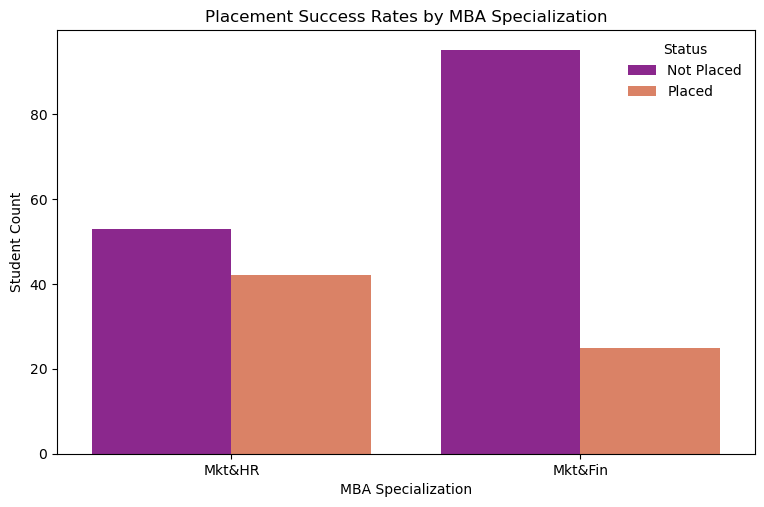

In [57]:
plt.figure(figsize=(9, 5.5))
sns.countplot(data=df, x='specialisation', hue='status', palette='plasma').set(
    title='Placement Success Rates by MBA Specialization',
    xlabel='MBA Specialization',
    ylabel='Student Count'
)
plt.legend(title='Status', labels=['Not Placed', 'Placed'], frameon=False)
plt.show()


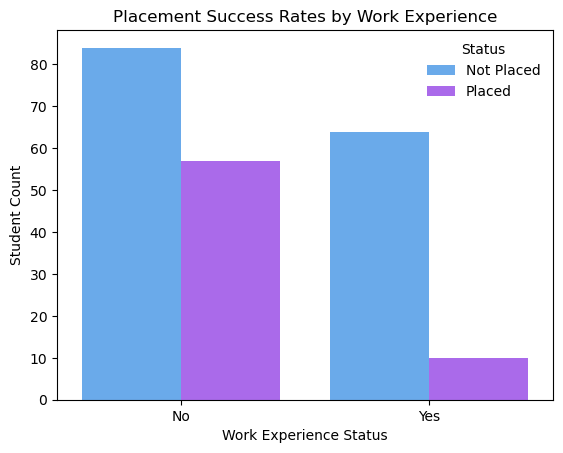

In [58]:
sns.countplot(data=df, x='workex', hue='status', palette='cool').set(
    title='Placement Success Rates by Work Experience',
    xlabel='Work Experience Status',
    ylabel='Student Count'
)
plt.legend(title='Status', labels=['Not Placed', 'Placed'], frameon=False)
plt.show()


Impact of Work Experience on Placement Status

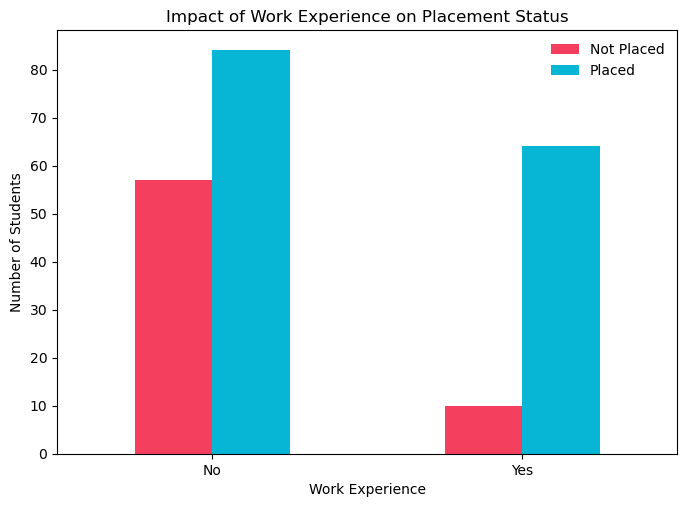

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean column names
df.columns = df.columns.str.strip()

# Create grouped data
workex_status = pd.crosstab(df['workex'], df['status'])

# Plot histogram (bar style histogram)
workex_status.plot(
    kind='bar',
    figsize=(8, 5.5),
    color=['#f43f5e', '#06b6d4']
)

plt.title('Impact of Work Experience on Placement Status')
plt.xlabel('Work Experience')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.legend(['Not Placed', 'Placed'], frameon=False)
plt.show()

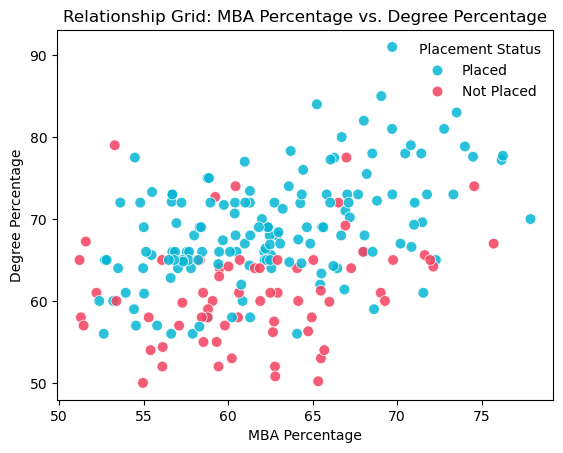

In [61]:
sns.scatterplot(
    data=df, 
    x='mba_p', 
    y='degree_p', 
    hue='status', 
    palette=['#06b6d4', '#f43f5e'], 
    alpha=0.85, 
    s=60
).set(
    title='Relationship Grid: MBA Percentage vs. Degree Percentage',
    xlabel='MBA Percentage',
    ylabel='Degree Percentage'
)
plt.legend(title='Placement Status', frameon=False)
plt.show()


Correlation Heatmap

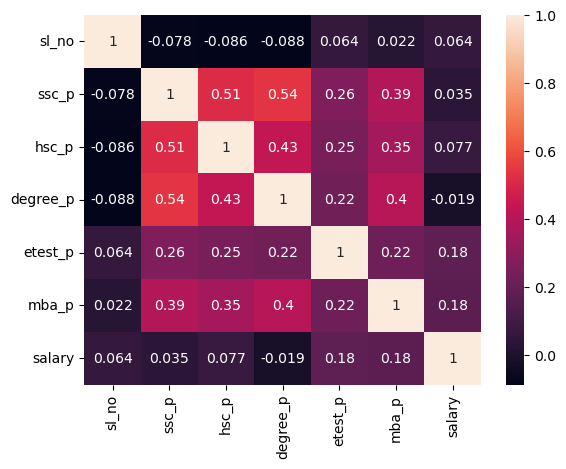

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# 5. Insights

Insight 1

Students with higher MBA percentages tend to have better placement rates

Insight 2

Students having work experience are more likely to get placed

Insight 3

Marketing & Finance specialization shows a higher placement ratio

Insight 4

Degree percentage and MBA percentage positively influence placement

Insight 5

Most salaries are concentrated in the middle range with a few high-salary outliers

## 6. Key Findings

Placement Rate -:
A majority of students in the dataset were successfully placed through campus recruitment

Academic Performance Matters -:
Students with higher SSC, HSC, Degree, and MBA percentages generally had better placement outcomes

Impact of Work Experience -:
Candidates with prior work experience showed a higher likelihood of being placed compared to those without experience

Role of Specialization -:
Certain specializations demonstrated higher placement rates, indicating that domain knowledge can influence employability

Salary Trends -:
Salary packages varied among placed students, with most offers concentrated within a moderate salary range

Gender Analysis -:
Placement opportunities were available across genders, with placement outcomes being influenced more by qualifications and skills than by gender alone

Strong Predictive Factors -:
MBA percentage, degree percentage, work experience, and specialization were among the most influential factors affecting placement status

## 7. Conclusion

The College Placement Analysis project examined factors affecting student placements using the Campus Recruitment Dataset. Exploratory Data Analysis revealed that academic performance, work experience, and specialization significantly influence placement outcomes. Students with higher MBA and degree percentages demonstrated better placement chances. Work experience also positively impacted employability. The analysis provides useful insights for students and institutions to improve placement performance and career readiness.